In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
dados = pd.read_csv('../AirPassengers.csv')
print(dados.head())

     Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121


In [100]:
# ver as ultimas datas
print(dados.tail())

       Month  #Passengers
139  1960-08          606
140  1960-09          508
141  1960-10          461
142  1960-11          390
143  1960-12          432


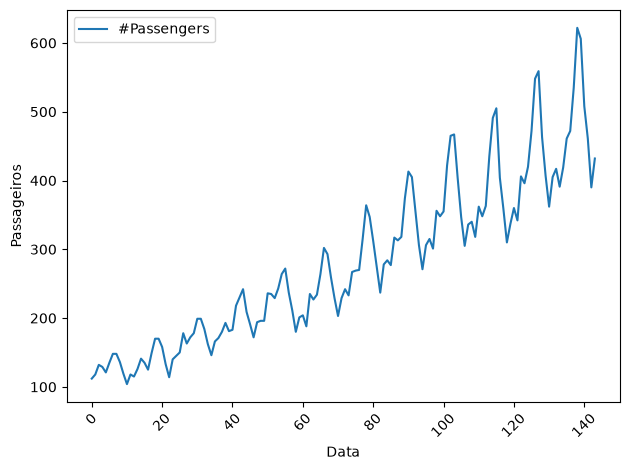

In [101]:
dados.plot()
plt.xticks(rotation=45)
plt.xlabel('Data')
plt.ylabel('Passageiros')
plt.tight_layout()
plt.show()

# SEPARA OS DADOS EM TREINO E TESTE PARA TESTAR A AUTO REGRESSÃO

In [103]:
# usa de 1949 até 1958 como treino e 1959 e 1960 como teste
datas_treino = dados[dados.Month < '1959-01-01' ].Month.values
X_treino = dados[dados.Month < '1959-01-01' ]['#Passengers'].values

datas_teste = dados[dados.Month >= '1959-01-01' ].Month.values
X_teste = dados[dados.Month >= '1959-01-01' ]['#Passengers'].values

# FAZ A AUTO REGRESSAO CONSIDERANDO SÓ OS DADOS DE TREINO

In [104]:
from statsmodels.tsa.ar_model import AutoReg

In [111]:
modelo = AutoReg(X_treino, 1) # AR(1), considera só o último dado pra prever o próximo
resultado = modelo.fit()
print(resultado.summary(), '\n')
print(f'AIC com AR(1) = {resultado.aic:.2f}')

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  121
Model:                     AutoReg(1)   Log Likelihood                -571.140
Method:               Conditional MLE   S.D. of innovations             28.235
Date:                Thu, 20 Aug 2026   AIC                           1148.281
Time:                        18:56:24   BIC                           1156.643
Sample:                             1   HQIC                          1151.677
                                  121                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.9412      7.182      1.941      0.052      -0.136      28.018
y.L1           0.9517      0.027     34.910      0.000       0.898       1.005
                                    Roots           

# TENTA PREVER OS DADOS USANDO SÓ O ULTIMO VALOR COMO REFERENCIA

In [107]:
X_pred = resultado.predict(start=len(X_treino), end=len(X_treino)+len(X_teste)-1)
print('Valores preditos pros anos 1959 e 1960\n', X_pred)

Valores preditos pros anos 1959 e 1960
 [356.55736878 353.28097652 350.16279583 347.19518693 344.37087896
 341.68295214 339.12482087 336.69021752 334.37317714 332.16802281
 330.06935174 328.07202202 326.17114005 324.36204852 322.64031504
 321.00172121 319.44225238 317.95808771 316.5455909  315.20130122
 313.92192507 312.70432788 311.54552645]


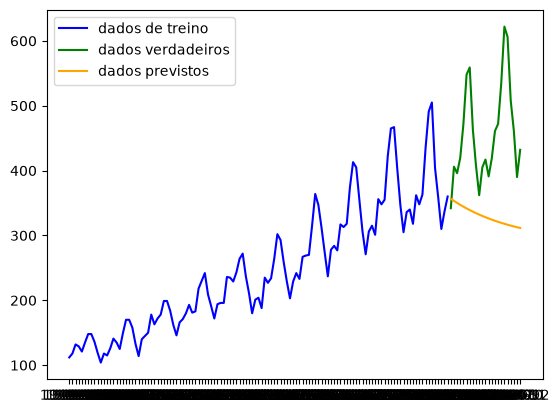

In [116]:
plt.plot(datas_treino, X_treino, color='blue', label='dados de treino')
plt.plot(datas_teste, X_teste, color='green', label='dados verdadeiros')
plt.plot(datas_teste, X_pred, color='orange', label='dados previstos')
plt.legend(loc="upper left") 
plt.show() # pessima previsão, passou longe. Previsão fez uma curva suave descendo

In [109]:
from sklearn.metrics import mean_squared_error
MSE = mean_squared_error(X_teste, X_pred)
RMSE = np.sqrt(MSE)
print(f'raiz dos erros ao quadrado com AR(1): {RMSE:.2f}')

raiz dos erros ao quadrado com AR(1): 148.96


# usando um lag maior (no caso 12, pegando o ano todo)

In [117]:
modelo = AutoReg(X_treino, 12) # csonidera o ano todo
resultado = modelo.fit()
print(resultado.summary(), '\n')

print(f'AIC com AR(12) = {resultado.aic:.2f}')

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  121
Model:                    AutoReg(12)   Log Likelihood                -432.954
Method:               Conditional MLE   S.D. of innovations             12.847
Date:                Thu, 20 Aug 2026   AIC                            893.908
Time:                        18:57:55   BIC                            931.587
Sample:                            12   HQIC                           909.188
                                  121                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.2209      4.021      3.537      0.000       6.340      22.102
y.L1           0.5059      0.085      5.940      0.000       0.339       0.673
y.L2          -0.2869      0.093     -3.082      0.0

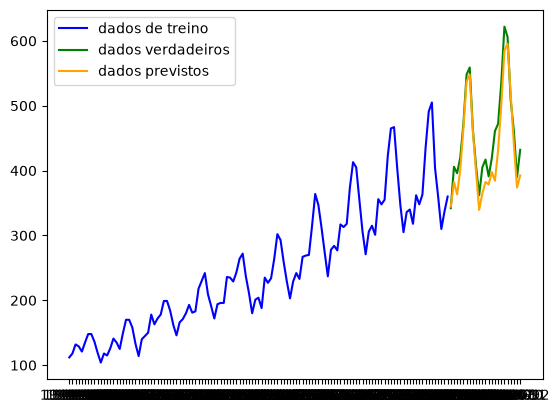

In [118]:
X_pred = resultado.predict(start=len(X_treino), end=len(X_treino)+len(X_teste)-1)

plt.plot(datas_treino, X_treino, color='blue', label='dados de treino')
plt.plot(datas_teste, X_teste, color='green', label='dados verdadeiros')
plt.plot(datas_teste, X_pred, color='orange', label='dados previstos')
plt.legend(loc="upper left") 
plt.show()

In [24]:
MSE = mean_squared_error(X_teste, X_pred)
RMSE = np.sqrt(MSE)
print(f'raiz dos erros ao quadrado com AR(12): {RMSE:.2f}')

raiz dos erros ao quadrado: 27.07


# encontrando o melhor lag

In [93]:
melhor_lag_segundo_aic = 0
melhor_aic = 999_999_999

melhor_lag_segundo_erro = 0
melhor_erro = 999_999_999

for i in range(1, len(X_treino)//2-1):
    modelo = AutoReg(X_treino, i)
    result = modelo.fit()
    aic = result.aic
    if(aic < melhor_aic):
        melhor_aic = aic
        melhor_lag_segundo_aic = i
    X_pred = result.predict(start=len(X_treino), end=len(X_treino)+len(X_teste)-1)
    MSE = mean_squared_error(X_teste, X_pred)
    RMSE = np.sqrt(MSE)
    if(RMSE < melhor_erro):
        melhor_erro = RMSE
        melhor_lag_segundo_erro = i
    print(f'I = {i}, AIC = {aic:.2f} ERRO: {RMSE:.2f}')

print(f'MELHOR LAG PELO AIC FOI {melhor_lag_segundo_aic}. AIC = {melhor_aic}')
print(f'MELHOR LAG PELO ERRO FOI {melhor_lag_segundo_erro}. ERRO = {melhor_erro}')

I = 1, AIC = 1138.94 ERRO: 160.50
I = 2, AIC = 1120.23 ERRO: 175.82
I = 3, AIC = 1109.58 ERRO: 159.72
I = 4, AIC = 1101.01 ERRO: 147.63
I = 5, AIC = 1085.58 ERRO: 108.29
I = 6, AIC = 1078.85 ERRO: 111.32
I = 7, AIC = 1070.69 ERRO: 98.98
I = 8, AIC = 1061.04 ERRO: 90.60
I = 9, AIC = 1018.18 ERRO: 59.69
I = 10, AIC = 1004.83 ERRO: 48.63
I = 11, AIC = 917.50 ERRO: 28.13
I = 12, AIC = 886.25 ERRO: 27.07
I = 13, AIC = 807.79 ERRO: 42.59
I = 14, AIC = 790.32 ERRO: 55.74
I = 15, AIC = 785.45 ERRO: 52.26
I = 16, AIC = 779.19 ERRO: 60.57
I = 17, AIC = 773.77 ERRO: 61.06
I = 18, AIC = 769.23 ERRO: 61.98
I = 19, AIC = 760.08 ERRO: 45.18
I = 20, AIC = 754.98 ERRO: 51.53
I = 21, AIC = 749.30 ERRO: 42.51
I = 22, AIC = 740.43 ERRO: 29.09
I = 23, AIC = 731.26 ERRO: 23.72
I = 24, AIC = 725.87 ERRO: 25.19
I = 25, AIC = 718.11 ERRO: 31.53
I = 26, AIC = 708.73 ERRO: 38.41
I = 27, AIC = 704.24 ERRO: 38.06
I = 28, AIC = 700.17 ERRO: 36.97
I = 29, AIC = 694.19 ERRO: 37.20
I = 30, AIC = 687.89 ERRO: 37.52
I =

In [94]:
modelo = AutoReg(X_treino, melhor_lag_segundo_aic)
resultado = modelo.fit()
print(resultado.summary())

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  120
Model:                    AutoReg(58)   Log Likelihood                -123.630
Method:               Conditional MLE   S.D. of innovations              1.777
Date:                Thu, 20 Aug 2026   AIC                            367.261
Time:                        18:45:21   BIC                            494.889
Sample:                            58   HQIC                           417.371
                                  120                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        101.1389     18.563      5.448      0.000      64.756     137.522
y.L1           0.2990      0.096      3.103      0.002       0.110       0.488
y.L2           0.5803      0.103      5.619      0.0

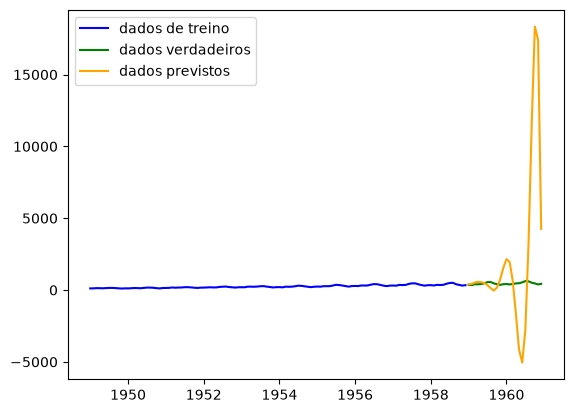

In [95]:
X_pred = resultado.predict(start=len(X_treino), end=len(X_treino)+len(X_teste)-1)

plt.plot(datas_treino, X_treino, color='blue', label='dados de treino')
plt.plot(datas_teste, X_teste, color='green', label='dados verdadeiros')
plt.plot(datas_teste, X_pred, color='orange', label='dados previstos')
plt.legend(loc="upper left") 
plt.show() # manteve o padrao da sazonalidade, mas explodiu ele muito mais que o normal

In [96]:
modelo = AutoReg(X_treino, melhor_lag_segundo_erro)
resultado = modelo.fit()
print(resultado.summary())

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  120
Model:                    AutoReg(38)   Log Likelihood                -278.040
Method:               Conditional MLE   S.D. of innovations              7.184
Date:                Thu, 20 Aug 2026   AIC                            636.079
Time:                        18:46:10   BIC                            732.348
Sample:                            38   HQIC                           674.730
                                  120                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.2007      3.791      1.372      0.170      -2.230      12.631
y.L1           0.5603      0.108      5.181      0.000       0.348       0.772
y.L2           0.2590      0.124      2.088      0.0

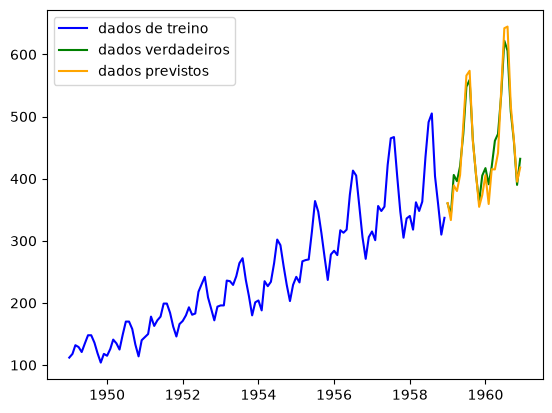

In [97]:
X_pred = resultado.predict(start=len(X_treino), end=len(X_treino)+len(X_teste)-1)

plt.plot(datas_treino, X_treino, color='blue', label='dados de treino')
plt.plot(datas_teste, X_teste, color='green', label='dados verdadeiros')
plt.plot(datas_teste, X_pred, color='orange', label='dados previstos')
plt.legend(loc="upper left") 
plt.show() # claramente o melhor resultado foi o com menor erro, nao o com menor AIC